In [2]:
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[1]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import xr_utils
from analysis.ou_tuning.contour_intersect import contour_intersections

r0 = 8
ou_mean = 0.0086, ou_std = 0.0007


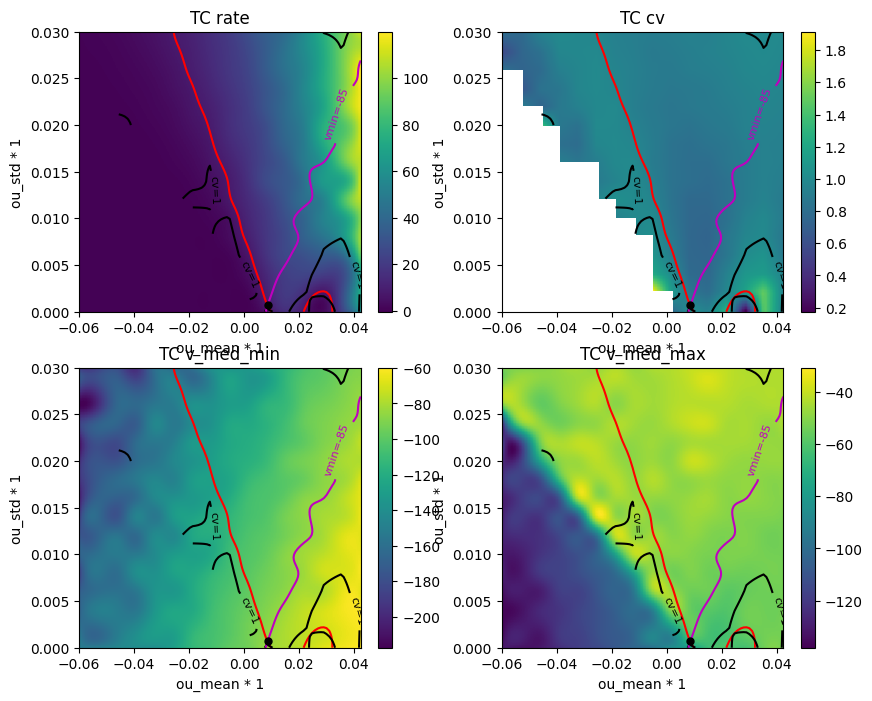

In [13]:
#dirpath_self = Path().resolve()
#dirpath_res_base = dirpath_root / 'exp_results'

exp_group = 'batch_i_ougrid_unconn_state1_mech1_nosub_wmult_0.25'
exp_name = 'all'
exp_name_sub = 'exp_ou_nmean_16_nstd_16'

pop = 'TC'
vmin0 = -85

#r0 = None
r0 = 8

def select_pts(r0=None):
    # Load batch result
    dirpath_res = (dirpath_root / 'exp_results' / exp_group / exp_name /
                   exp_name_sub / 'combined')
    fpath_res = dirpath_res / 'rates_cvs_all.nc'
    X = xr.load_dataset(fpath_res)

    # Load target rate
    if r0 is None:
        dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
        fpath_target = dirpath_cfg / 'target_state_1.csv'
        df = pd.read_csv(fpath_target)
        df = df.set_index('pop_name')
        r0 = df.loc[pop]['target_rate']

    print(f'r0 = {r0}')

    vars = ['rate', 'cv', 'v_med_min', 'v_med_max']
    D = {}

    # Extract variables, assign (ou_mean, ou_std) coords
    for v in vars:
        X_ = X[v].sel(pop=pop)
        X_ = X_.rename(ou_mean_ind='ou_mean', ou_std_ind='ou_std')
        X_ = X_.assign_coords(
            ou_mean=X['ou_mean'].sel(pop=pop).values,
            ou_std=X['ou_std'].sel(pop=pop).values
        )
        D[v] = X_.T

    # Upsample data
    sz_new = 100
    ou_mean = D['rate'].ou_mean.values
    ou_std = D['rate'].ou_std.values
    ou_mean_new = np.linspace(ou_mean.min(), ou_mean.max(), sz_new)
    ou_std_new = np.linspace(ou_std.min(), ou_std.max(), sz_new)
    for v, X_ in D.items():
        try:
            D[v] = X_.interp(ou_mean=ou_mean_new, ou_std=ou_std_new, method='cubic')
        except:
            D[v] = X_.interp(ou_mean=ou_mean_new, ou_std=ou_std_new, method='linear')

    pts = contour_intersections(D['rate'], D['v_med_min'], r0, vmin0)
    for _, pt in pts.iterrows():
        print(f'ou_mean = {pt["x"]:.4f}, ou_std = {pt["y"]:.4f}')

    # Plot 2-d maps of r, cv, and v stats
    fig = plt.figure(figsize=(10,8))
    axes = []
    for n, (v, X_) in enumerate(D.items()):
        ax = plt.subplot(2, 2, n + 1)
        axes.append(ax)
        xr_utils.plot_xr(X_, show_ax_names=True)
        cc = xr_utils.plot_xr_contour(D['rate'], '', [r0], colors=['r'])
        xr_utils.plot_xr_contour(D['cv'], 'cv', [1], colors=['k'])
        xr_utils.plot_xr_contour(D['v_med_min'], 'vmin', [vmin0], colors=['m'])
        plt.title(f'{pop} {v}')
        # Plot the selected points
        for _, pt in pts.iterrows():
            plt.plot(pt['x'], pt['y'], 'k.', markersize=10)
    plt.show()

select_pts(r0)

In [7]:
dirpath_self = Path().resolve()
dirpath_res_base = dirpath_root / 'exp_results'

exp_group = dirpath_self.name
exp_name_sub = 'exp_ou_nmean_10_nstd_10'

exp_name = 'thal'
pop = 'IREM'
vmin0 = -150

# Load batch result
dirpath_res = (dirpath_res_base / exp_group / exp_name
            / exp_name_sub / 'combined')
fpath_res = dirpath_res / 'rates_cvs_all.nc'
X = xr.load_dataset(fpath_res)

In [13]:
X.pop.values

array(['TC', 'TCM', 'HTC', 'TI', 'TIM', 'IRE', 'IREM'], dtype=object)